# DELHIVERY - UNIT ECONOMICS ANALYSIS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import os

In [2]:
os.makedirs('charts', exist_ok=True)

BLUE = '#1565C0'
RED = '#C62828'
GREEN = '#2E7D32'
ORANGE = '#E65100'
GREY = '#546E7A'
LIGHT_GREY = '#ECEFF1'
DARK_GREY = '#37474F'

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

In [3]:
df = pd.read_csv('../2. Data/Unit_Economics_Quaterly.csv')

df.columns = [
    'Quarter',
    'Shipments_Mn',
    'Revenue_Per_Shipment',
    'EBITDA_Per_Shipment',
    'Express_Revenue_Cr',
    'Express_EBITDA_Cr',
    'Total_Revenue_Cr',
    'Adj_EBITDA_Cr'
]

print("Data loaded successfully:")
print(df.head())
print(f"\nTotal quarters: {len(df)}")
print(f"\nRevenue per shipment range: ₹{df['Revenue_Per_Shipment'].min():.1f} - ₹{df['Revenue_Per_Shipment'].max():.1f}")
print(f"EBITDA per shipment range: ₹{df['EBITDA_Per_Shipment'].min():.2f} - ₹{df['EBITDA_Per_Shipment'].max():.2f}")

Data loaded successfully:
   Quarter  Shipments_Mn  Revenue_Per_Shipment  EBITDA_Per_Shipment  \
0  Q1 FY23           152                 69.14                -0.39   
1  Q2 FY23           161                 69.88                 5.34   
2  Q3 FY23           170                 70.59                 8.18   
3  Q4 FY23           180                 65.39                11.39   
4  Q1 FY24           182                 66.04                11.92   

   Express_Revenue_Cr  Express_EBITDA_Cr  Total_Revenue_Cr  Adj_EBITDA_Cr  
0                1051                 -6              1746           -217  
1                1125                 86              1796           -125  
2                1200                139              1822            -67  
3                1177                205              1860              6  
4                1202                217              1930            -25  

Total quarters: 17

Revenue per shipment range: ₹58.0 - ₹72.2
EBITDA per shipment range: ₹

In [4]:
quarters = df['Quarter'].tolist()

### Chart 1: REVENUE vs COST per Shipment

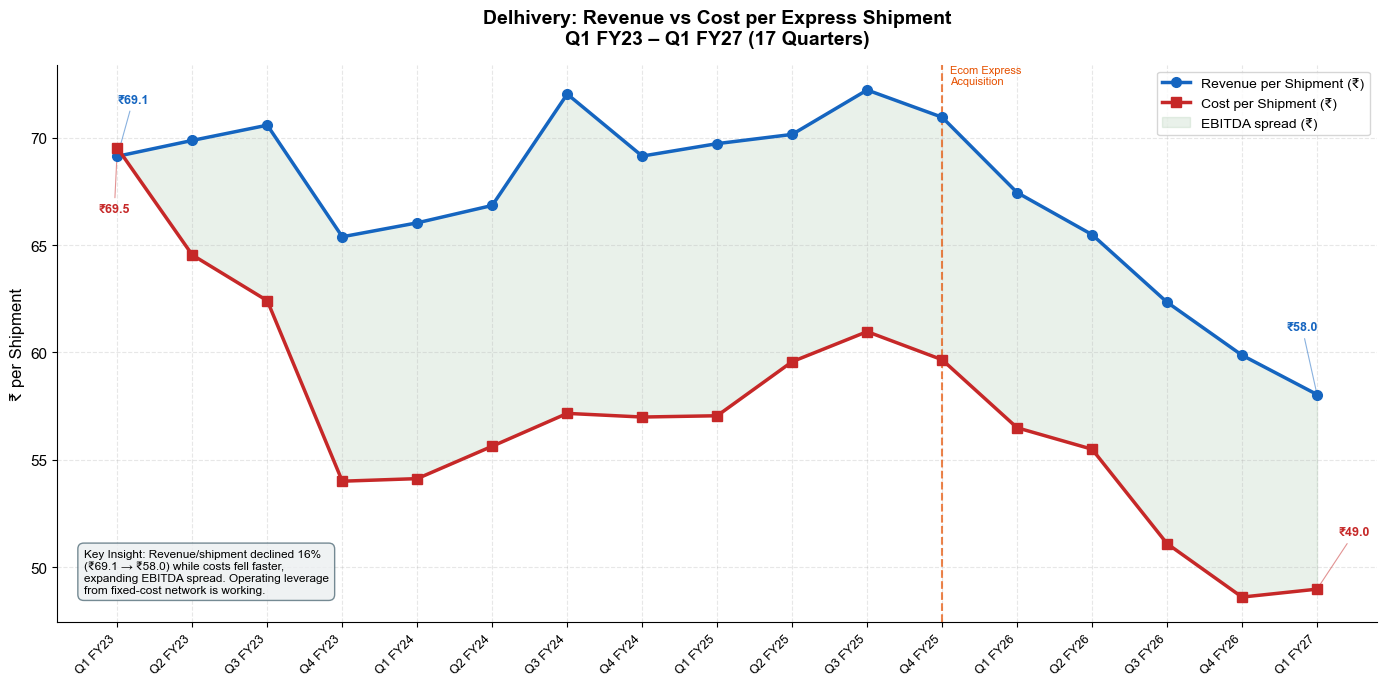

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

df['Cost_Per_Shipment'] = df['Revenue_Per_Shipment'] - df['EBITDA_Per_Shipment']

ax.plot(range(len(quarters)),
        df['Revenue_Per_Shipment'],
        color=BLUE,
        linewidth=2.5,
        marker='o',
        markersize=7,
        label='Revenue per Shipment (₹)',
        zorder=5)

ax.plot(range(len(quarters)),
        df['Cost_Per_Shipment'],
        color=RED,
        linewidth=2.5,
        marker='s',
        markersize=7,
        label='Cost per Shipment (₹)',
        zorder=5)

ax.fill_between(range(len(quarters)),
                df['Revenue_Per_Shipment'],
                df['Cost_Per_Shipment'],
                alpha=0.1,
                color=GREEN,
                label='EBITDA spread (₹)')

ax.annotate(f"₹{df['Revenue_Per_Shipment'].iloc[0]:.1f}",
            xy=(0, df['Revenue_Per_Shipment'].iloc[0]),
            xytext=(0, df['Revenue_Per_Shipment'].iloc[0] + 2.5),
            fontsize=9, color=BLUE, fontweight='bold',
            arrowprops=dict(arrowstyle='-',
                            color=BLUE,
                            lw=0.8,
                            alpha=0.5))

ax.annotate(f"₹{df['Revenue_Per_Shipment'].iloc[-1]:.1f}",
            xy=(len(quarters)-1, df['Revenue_Per_Shipment'].iloc[-1]),
            xytext=(len(quarters)-1.2, df['Revenue_Per_Shipment'].iloc[-1] + 3),
            fontsize=9, color=BLUE, fontweight='bold',
            ha='center',
            arrowprops=dict(arrowstyle='-',
                          color=BLUE,
                          lw=0.8,
                          alpha=0.5))

ax.annotate(f"₹{df['Cost_Per_Shipment'].iloc[0]:.1f}",
            xy=(0, df['Cost_Per_Shipment'].iloc[0]),
            xytext=(-0.25, df['Cost_Per_Shipment'].iloc[0] - 3),
            fontsize=9, color=RED, fontweight='bold',
            arrowprops=dict(arrowstyle='-',
                          color=RED,
                          lw=0.8,
                          alpha=0.5))

ax.annotate(f"₹{df['Cost_Per_Shipment'].iloc[-1]:.1f}",
            xy=(len(quarters)-1, df['Cost_Per_Shipment'].iloc[-1]),
            xytext=(len(quarters) - 0.5, df['Cost_Per_Shipment'].iloc[-1] + 2.5),
            fontsize=9, color=RED, fontweight='bold',
            ha='center',
            arrowprops=dict(arrowstyle='-',
                          color=RED,
                          lw=0.8,
                          alpha=0.5))

ecom_idx = quarters.index('Q4 FY25')
ax.axvline(x=ecom_idx,
           color=ORANGE,
           linewidth=1.5,
           linestyle='--',
           alpha=0.7)
ax.text(ecom_idx + 0.1,
        ax.get_ylim()[1] if ax.get_ylim()[1] > 50 else 68,
        'Ecom Express\nAcquisition',
        fontsize=8,
        color=ORANGE,
        va='top')

ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('₹ per Shipment', fontsize=12)
ax.set_title('Delhivery: Revenue vs Cost per Express Shipment\n'
             'Q1 FY23 – Q1 FY27 (17 Quarters)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10)

insight_text = (
    "Key Insight: Revenue/shipment declined 16%\n"
    "(₹69.1 → ₹58.0) while costs fell faster,\n"
    "expanding EBITDA spread. Operating leverage\n"
    "from fixed-cost network is working."
)
ax.text(0.02, 0.05,
        insight_text,
        transform=ax.transAxes,
        fontsize=8.5,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor=LIGHT_GREY,
                  edgecolor=GREY,
                  alpha=0.8))

plt.tight_layout()
plt.savefig('charts/chart1_revenue_cost_per_shipment.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='white')
plt.show()

### Chart 2: EBITDA per Shipment - Path to Profitability

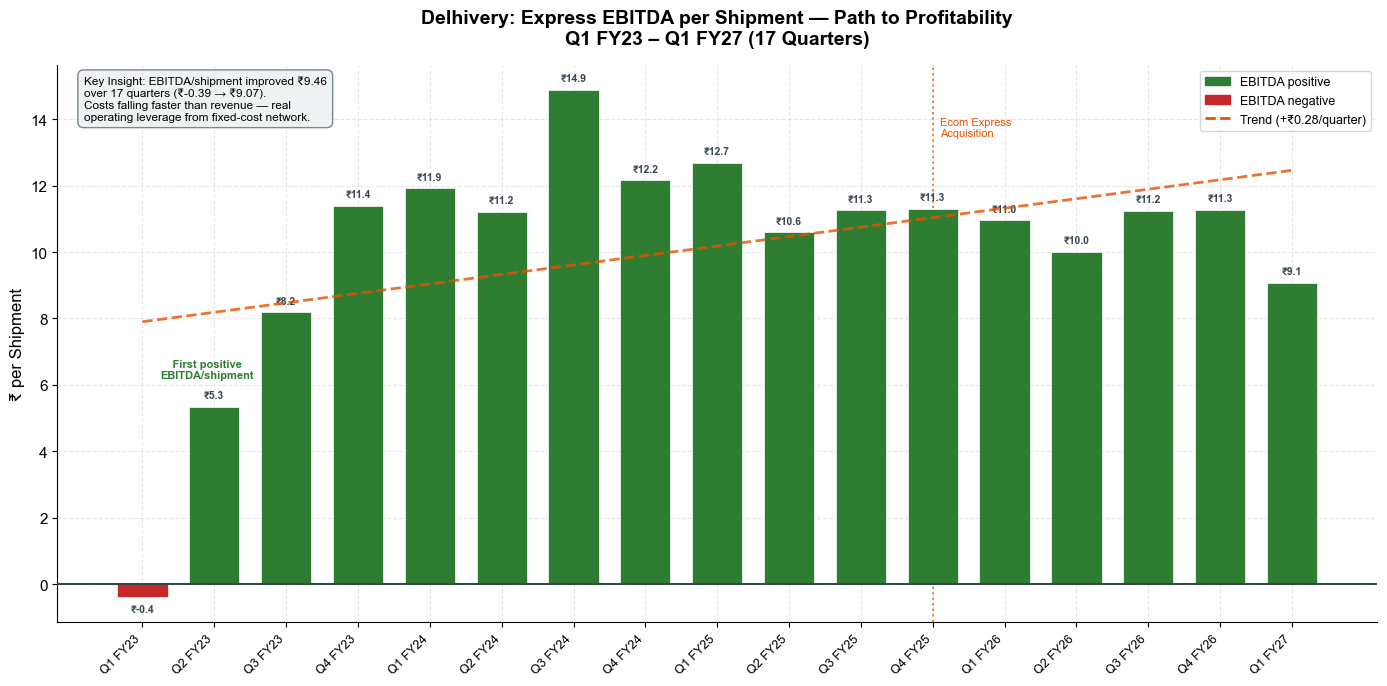

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors = [GREEN if x >= 0 else RED
          for x in df['EBITDA_Per_Shipment']]

bars = ax.bar(range(len(quarters)),
              df['EBITDA_Per_Shipment'],
              color=colors,
              width=0.7,
              zorder=3,
              edgecolor='white',
              linewidth=0.5)

ax.axhline(y=0, color=DARK_GREY, linewidth=1.5, zorder=4)

for i, (bar, val) in enumerate(zip(bars, df['EBITDA_Per_Shipment'])):
    offset = 0.2 if val >= 0 else -0.2
    ax.text(bar.get_x() + bar.get_width()/2,
            val + offset,
            f'₹{val:.1f}',
            ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=7.5,
            fontweight='bold',
            color=DARK_GREY)

z = np.polyfit(range(len(quarters)), df['EBITDA_Per_Shipment'], 1)
p = np.poly1d(z)
ax.plot(range(len(quarters)),
        p(range(len(quarters))),
        color=ORANGE,
        linewidth=2,
        linestyle='--',
        alpha=0.8,
        label=f'Trend line (slope: +₹{z[0]:.2f}/quarter)',
        zorder=5)

first_positive = df[df['EBITDA_Per_Shipment'] > 0].index[0]
ax.annotate('    First positive\nEBITDA/shipment',
            xy=(first_positive, df['EBITDA_Per_Shipment'].iloc[first_positive]),
            xytext=(first_positive - 0.75, 6.2),
            fontsize=8,
            color=GREEN,
            fontweight='bold')

ax.axvline(x=ecom_idx,
           color=ORANGE,
           linewidth=1.5,
           linestyle=':',
           alpha=0.7)
ax.text(ecom_idx + 0.1,
        ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 10 else 13,
        'Ecom Express\nAcquisition',
        fontsize=8,
        color=ORANGE,
        va='top')

ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('₹ per Shipment', fontsize=12)
ax.set_title('Delhivery: Express EBITDA per Shipment — Path to Profitability\n'
             'Q1 FY23 – Q1 FY27 (17 Quarters)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10)

positive_patch = mpatches.Patch(color=GREEN, label='EBITDA positive')
negative_patch = mpatches.Patch(color=RED, label='EBITDA negative')
ax.legend(handles=[positive_patch, negative_patch,
                   plt.Line2D([0], [0],
                              color=ORANGE,
                              linewidth=2,
                              linestyle='--',
                              label=f'Trend (+₹{z[0]:.2f}/quarter)')],
          loc='upper right',
          fontsize=9)

total_improvement = (df['EBITDA_Per_Shipment'].iloc[-1] -
                     df['EBITDA_Per_Shipment'].iloc[0])
insight_text = (
    f"Key Insight: EBITDA/shipment improved ₹{total_improvement:.2f}\n"
    f"over 17 quarters (₹{df['EBITDA_Per_Shipment'].iloc[0]:.2f} → "
    f"₹{df['EBITDA_Per_Shipment'].iloc[-1]:.2f}).\n"
    "Costs falling faster than revenue — real\n"
    "operating leverage from fixed-cost network."
)
ax.text(0.02, 0.98,
        insight_text,
        transform=ax.transAxes,
        fontsize=8.5,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor=LIGHT_GREY,
                  edgecolor=GREY,
                  alpha=0.8))

plt.tight_layout()
plt.savefig('charts/chart2_ebitda_per_shipment.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='white')
plt.show()

### Chart 3: Volume Growth + Breakeven Projection

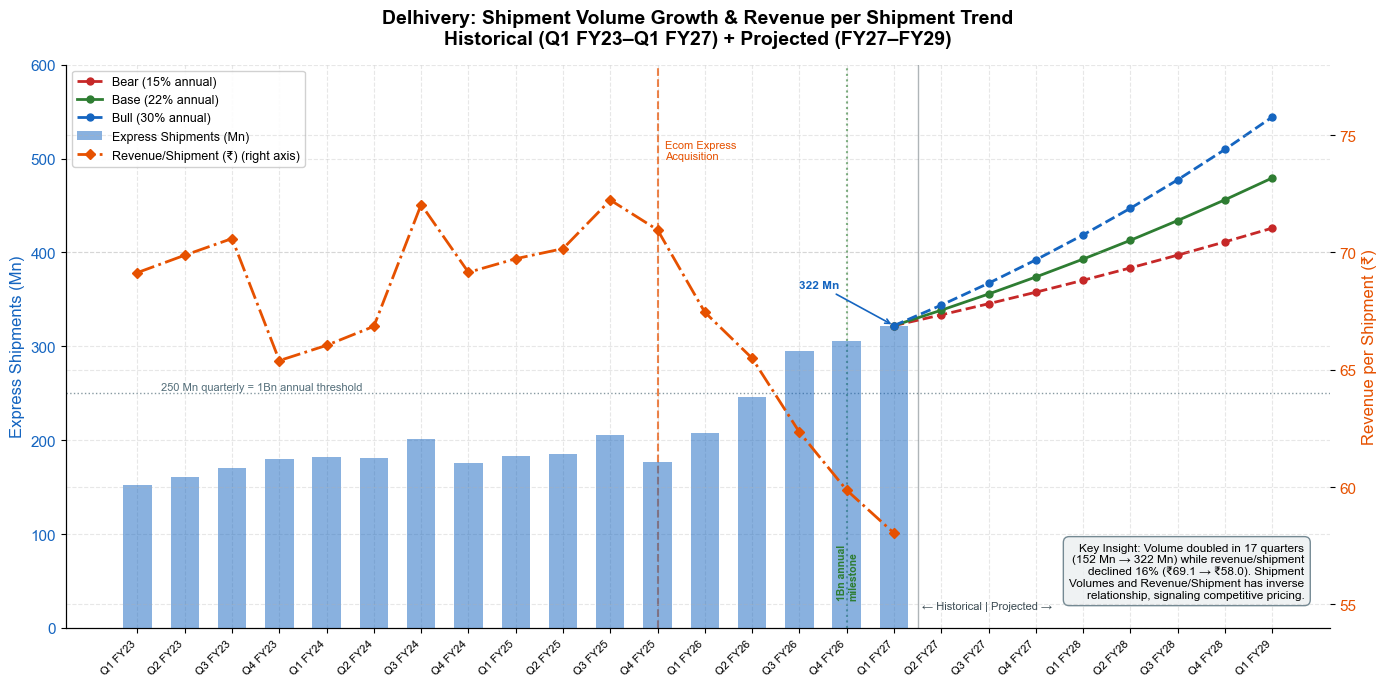

In [7]:
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

ax2 = ax1.twinx()

ax1.bar(range(len(quarters)),
        df['Shipments_Mn'],
        color=BLUE,
        alpha=0.5,
        width=0.6,
        label='Express Shipments (Mn)',
        zorder=3)

future_quarters = ['Q2 FY27', 'Q3 FY27', 'Q4 FY27',
                   'Q1 FY28', 'Q2 FY28', 'Q3 FY28',
                   'Q4 FY28', 'Q1 FY29']

current_volume = df['Shipments_Mn'].iloc[-1]
start_idx = len(quarters) - 1

scenarios = {
    'Bear (15% annual)': {'rate': 0.15, 'color': RED,   'style': '--'},
    'Base (22% annual)': {'rate': 0.22, 'color': GREEN, 'style': '-'},
    'Bull (30% annual)': {'rate': 0.30, 'color': BLUE,  'style': '--'}
}

all_quarters = quarters + future_quarters

for scenario_name, params in scenarios.items():
    quarterly_growth = (1 + params['rate']) ** 0.25 - 1
    projected = [current_volume]
    for _ in range(len(future_quarters)):
        projected.append(projected[-1] * (1 + quarterly_growth))

    x_positions = list(range(start_idx,
                             start_idx + len(future_quarters) + 1))

    ax1.plot(x_positions,
             projected,
             color=params['color'],
             linewidth=2,
             linestyle=params['style'],
             label=scenario_name,
             zorder=5,
             marker='o',
             markersize=5)

ax2.plot(range(len(quarters)),
         df['Revenue_Per_Shipment'],
         color=ORANGE,
         linewidth=2,
         linestyle='-.',
         marker='D',
         markersize=5,
         label='Revenue/Shipment (₹) (right axis)',
         zorder=5)

ax1.set_ylim(0, 600)
ax2.set_ylim(54, 78)

ax1.axhline(y=250,
            color=GREY,
            linewidth=1,
            linestyle=':',
            alpha=0.7)
ax1.text(0.5, 253,
         '250 Mn quarterly = 1Bn annual threshold',
         fontsize=8,
         color=GREY)

milestone_idx = quarters.index('Q4 FY26')
ax1.axvline(x=milestone_idx,
            color=GREEN,
            linewidth=1.5,
            linestyle=':',
            alpha=0.6)
ax1.text(milestone_idx - 0.2,
         30,
         '1Bn annual\nmilestone',
         fontsize=7.5,
         color=GREEN,
         fontweight='bold',
         rotation=90,
         va='bottom')

ax1.axvline(x=ecom_idx,
            color=ORANGE,
            linewidth=1.5,
            linestyle='--',
            alpha=0.7)
ax1.text(ecom_idx + 0.15,
         520,
         'Ecom Express\nAcquisition',
         fontsize=8,
         color=ORANGE,
         va='top')

ax1.axvline(x=start_idx + 0.5,
            color=DARK_GREY,
            linewidth=1,
            linestyle='-',
            alpha=0.4)
ax1.text(start_idx + 0.6,
         20,
         '← Historical | Projected →',
         fontsize=8,
         color=DARK_GREY)

ax1.annotate(f'{int(current_volume)} Mn',
             xy=(start_idx, current_volume),
             xytext=(start_idx - 2, current_volume + 40),
             fontsize=8.5,
             color=BLUE,
             fontweight='bold',
             arrowprops=dict(arrowstyle='->',
                             color=BLUE,
                             lw=1.2))

ax1.set_xticks(range(len(all_quarters)))
ax1.set_xticklabels(all_quarters,
                    rotation=45,
                    ha='right',
                    fontsize=8)
ax1.set_ylabel('Express Shipments (Mn)',
               fontsize=12,
               color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax2.set_ylabel('Revenue per Shipment (₹)',
               fontsize=12,
               color=ORANGE)
ax2.tick_params(axis='y', labelcolor=ORANGE)

ax1.set_title('Delhivery: Shipment Volume Growth & Revenue per Shipment Trend\n'
              'Historical (Q1 FY23–Q1 FY27) + Projected (FY27–FY29)',
              fontsize=14,
              fontweight='bold',
              pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2,
           labels1 + labels2,
           loc='upper left',
           fontsize=9,
           framealpha=0.9)

insight_text = (
    "Key Insight: Volume doubled in 17 quarters\n"
    "(152 Mn → 322 Mn) while revenue/shipment\n"
    "declined 16% (₹69.1 → ₹58.0). Shipment\n"
    "Volumes and Revenue/Shipment has inverse\n"
    "relationship, signaling competitive pricing."
)
ax1.text(0.98, 0.05,
         insight_text,
         transform=ax1.transAxes,
         fontsize=8.5,
         verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5',
                   facecolor=LIGHT_GREY,
                   edgecolor=GREY,
                   alpha=0.8))

plt.tight_layout()
plt.savefig('charts/chart3_volume_growth_projection.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='white')
plt.show()

In [8]:

print("\n" + "="*60)
print("UNIT ECONOMICS SUMMARY")
print("="*60)

print(f"\nSHIPMENT VOLUME:")
print(f"  Q1 FY23: {df['Shipments_Mn'].iloc[0]} Mn")
print(f"  Q1 FY27: {df['Shipments_Mn'].iloc[-1]} Mn")
print(f"  Growth: {((df['Shipments_Mn'].iloc[-1]/df['Shipments_Mn'].iloc[0])-1)*100:.1f}%")

print(f"\nREVENUE PER SHIPMENT:")
print(f"  Q1 FY23: ₹{df['Revenue_Per_Shipment'].iloc[0]:.2f}")
print(f"  Q1 FY27: ₹{df['Revenue_Per_Shipment'].iloc[-1]:.2f}")
print(f"  Change: {((df['Revenue_Per_Shipment'].iloc[-1]/df['Revenue_Per_Shipment'].iloc[0])-1)*100:.1f}%")

print(f"\nEBITDA PER SHIPMENT:")
print(f"  Q1 FY23: ₹{df['EBITDA_Per_Shipment'].iloc[0]:.2f}")
print(f"  Q1 FY27: ₹{df['EBITDA_Per_Shipment'].iloc[-1]:.2f}")
print(f"  Improvement: ₹{df['EBITDA_Per_Shipment'].iloc[-1] - df['EBITDA_Per_Shipment'].iloc[0]:.2f}")

print(f"\nQUARTERLY EBITDA IMPROVEMENT RATE:")
quarters_count = len(df) - 1
total_improvement = (df['EBITDA_Per_Shipment'].iloc[-1] -
                     df['EBITDA_Per_Shipment'].iloc[0])
print(f"  Average: ₹{total_improvement/quarters_count:.2f} per quarter")
print(f"  Total over {quarters_count} quarters: ₹{total_improvement:.2f}")

print(f"\nADJ EBITDA (COMPANY LEVEL):")
print(f"  Q1 FY23: ₹{df['Adj_EBITDA_Cr'].iloc[0]} Cr")
print(f"  Q1 FY27: ₹{df['Adj_EBITDA_Cr'].iloc[-1]} Cr")
print(f"  Turned positive: {df[df['Adj_EBITDA_Cr'] > 0]['Quarter'].iloc[0]}")

print("\n"+"="*60)


UNIT ECONOMICS SUMMARY

SHIPMENT VOLUME:
  Q1 FY23: 152 Mn
  Q1 FY27: 322 Mn
  Growth: 111.8%

REVENUE PER SHIPMENT:
  Q1 FY23: ₹69.14
  Q1 FY27: ₹58.04
  Change: -16.1%

EBITDA PER SHIPMENT:
  Q1 FY23: ₹-0.39
  Q1 FY27: ₹9.07
  Improvement: ₹9.46

QUARTERLY EBITDA IMPROVEMENT RATE:
  Average: ₹0.59 per quarter
  Total over 16 quarters: ₹9.46

ADJ EBITDA (COMPANY LEVEL):
  Q1 FY23: ₹-217 Cr
  Q1 FY27: ₹76 Cr
  Turned positive: Q4 FY23

